# 1D convolution problem - 2 parameter prior

Recover 1D function from blurred, noisy data along with prior precision hyperparameter

Gaussian prior, gamma hyperpriors

Computes the distribution explicitly as in INLA

See "Efficient Marginalization-Based MCMC Methods for Hierarchical Bayesian Inverse Problems", Saibaba et al. 2019 and
"MCMC-Based Image Reconstruction with Uncertainty Quantification", Bardsley, 2012 for the example problem

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

In [2]:
# Define the true signal (1D image)
def true_signal(x):
    return 50*np.exp(-((x-0.75)/0.1)**2) + 37*np.logical_and(x>0.1,x<0.25) + 13*np.logical_and(x>0.3,x<0.32) 

# Generate observed blurred data
def generate_blurred_data(true_signal, x, A, lam):
    noise_std = 1/np.sqrt(lam)
    blurred_signal = np.dot(A,true_signal(x))
    noise = np.random.normal(0, noise_std, len(x))
    return blurred_signal + noise

# Define a Gaussian blur kernel
def gaussian_kernel(x, gamma):
    return np.exp(-x**2 / (2 * gamma**2))/np.sqrt(np.pi*gamma**2)

# Gibbs sampler
def gibbs(delta_initial, observed_data, A, L, N, lam, alpha_del, beta_del, n_iter=10):
    theta_samples = np.zeros((N,n_iter))
    delta_samples = np.zeros(n_iter+1)
    delta_samples[0] = delta_initial
    
    for idx in range(n_iter):
        K = np.linalg.cholesky(lam*np.dot(np.transpose(A),A) + delta_samples[idx]*L)
        w = np.dot(K,np.random.randn(N))
        y = solve_triangular(K,lam*np.dot(np.transpose(A),observed_data) + w, lower=True)
        theta_samples[:,idx] = solve_triangular(K,y,lower=True,trans='T')
        
        delta_shape = N/2 + alpha_del
        delta_rate = 0.5 * np.dot(theta_samples[:,idx],np.dot(L,theta_samples[:,idx])) + beta_del
        
        delta_samples[idx+1] = np.random.gamma(delta_shape, 1/delta_rate)
        
    return theta_samples, delta_samples

# Explicitly compute log p(delta, gamma | data)
def logpi_gamma_delta(gamma, delta, lam, A, data):
    # compute prior precision L
    Lap = 2*np.diag(np.ones(N)) - np.diag(np.ones(N-1), k=1) - np.diag(np.ones(N-1), k=-1)
    Id = np.diag(np.ones(N))
    L = delta*Id + gamma*Lap
    L = np.dot(L,L)
    
    # compute posterior precision and mean
    Lpost = lam*np.dot(np.transpose(A),A) + L
    xpost = lam*np.dot(np.transpose(A),data)
    xpost = np.linalg.solve(Lpost, xpost)
    
    # compute negative log of determinant ratio
    (sdetL, logdetL) = np.linalg.slogdet(L)
    (sdetLpost, logdetLpost) = np.linalg.slogdet(Lpost)
    logpi = - 0.5*logdetLpost + 0.5*logdetL + N/2*np.log(lam) + \
        (alpha_del-1)*np.log(delta) + (alpha_gam-1)*np.log(gamma)
    
    # compute data, posterior mean, and hyperprior terms
    logpi += -0.5*(lam*np.dot(data,data) - np.dot(xpost, np.dot(Lpost, xpost))) - beta_del*delta - beta_gam*gamma
    
    return logpi

In [3]:
# Parameters and generating noisy blurred data

np.random.seed(42)
# discretization dimension
N = 80
x = np.linspace(0, 1, N)
# width of convolution stencil -- in this case the full interval
kernel_size = N
# stdev of gaussian convolution kernel
kernel_gamma = 0.03
# noise precision
lam = 5.35
# hyperprior parameters
alpha_del = 1
alpha_gam = 1
beta_del = 1e-4
beta_gam = 1e-4
# number of Gibbs iterations
iters = 1000

# blurring matrix
A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        d = min(np.abs(i-j),N-np.abs(i-j))
        A[i,j] = gaussian_kernel(d/N, kernel_gamma)/N
# fix scaling (since h=1/N isn't small enough for the kernel to integrate to ~1 numerically)
A = A/np.sum(A[0,:]) 

# Generate data
observed_data = generate_blurred_data(true_signal, x, A, lam)

# # Initial guess for the hyperparameters
delta_initial = 0.4

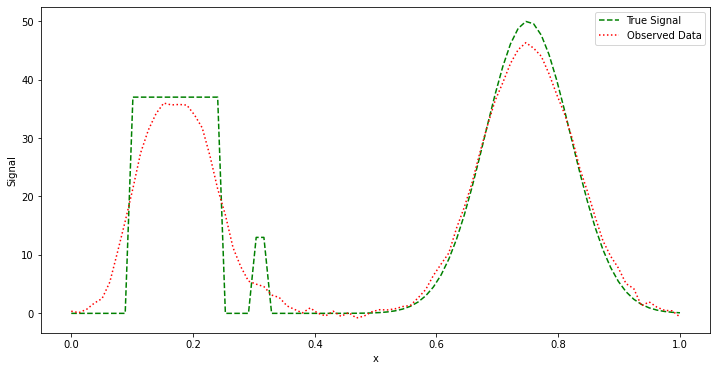

In [46]:
# Plot observations
plt.figure(figsize=(12, 6))
plt.plot(x, true_signal(x), label="True Signal", linestyle='dashed', color='green')
plt.plot(x, observed_data, label="Observed Data", linestyle='dotted', color='red')
plt.legend()
plt.xlabel("x")
plt.ylabel("Signal")
plt.show()

# INLA

In [42]:
del_range = np.linspace(0.0001, 0.025, 30)
gam_range = np.linspace(0.0001, 0.4, 30)

# compute - log pi(gamma, delta | data)
neglogpi = np.zeros((len(gam_range),len(del_range)))
for i in range(len(gam_range)):
    for j in range(len(del_range)):
        neglogpi_ij = -logpi_gamma_delta(gam_range[i],del_range[j], lam, A, observed_data)
        neglogpi[i,j] = neglogpi_ij

Text(0.5, 0, '$\\delta$')

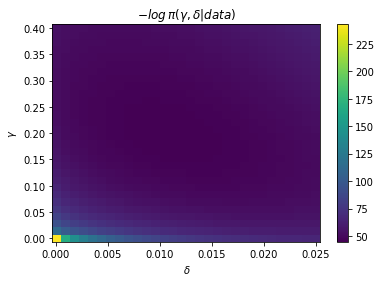

In [43]:
# plot -log pi(gamma, delta | data)
plt.pcolormesh(del_range,gam_range,neglogpi)
plt.colorbar()
plt.title(r'$-log \, \pi(\gamma, \delta | data)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

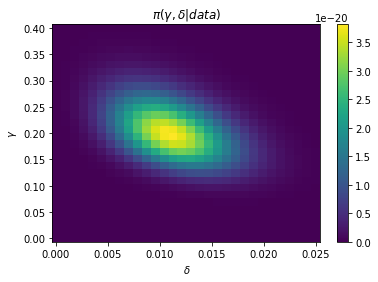

In [45]:
# plot pi(gamma, delta | data)
plt.pcolormesh(del_range,gam_range,np.exp(-neglogpi))
plt.colorbar()
plt.title(r'$\pi(\gamma, \delta | data)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')